In [1]:
import pandas as pd  
import numpy as np   
import seaborn as sns  
 
file_path = r"C:\Users\chere\Downloads\hci_crime_752_pl_co_re_ca_2000-2013_21oct15-ada (2).xlsx" 
df= pd.read_excel(file_path)
df.head() 

,ind_id,ind_definition,reportyear,race_eth_code,race_eth_name,geotype,geotypevalue,geoname,county_fips,county_name,...,denominator,rate,ll_95ci,ul_95ci,se,rse,ca_decile,ca_rr,dof_population,version
0,752,"Number of Violent Crimes per 1,000 Population",2000.0,9.0,Total,CA,6.0,California,NaN,NaN,...,33847694.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33873086.0,2015-10-21 11:57:16
1,752,"Number of Violent Crimes per 1,000 Population",2000.0,9.0,Total,CA,6.0,California,NaN,NaN,...,33847694.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33873086.0,2015-10-21 11:57:16
2,752,"Number of Violent Crimes per 1,000 Population",2000.0,9.0,Total,CA,6.0,California,NaN,NaN,...,33847694.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33873086.0,2015-10-21 11:57:16
3,752,"Number of Violent Crimes per 1,000 Population",2000.0,9.0,Total,CA,6.0,California,NaN,NaN,...,33847694.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33873086.0,2015-10-21 11:57:16
4,752,"Number of Violent Crimes per 1,000 Population",2000.0,9.0,Total,CA,6.0,California,NaN,NaN,...,33847694.0,6.217499,6.190935,6.244063,0.013553,0.217985,NaN,1.0,33873086.0,2015-10-21 11:57:16


In [115]:
 df['rate'] = df['rate'].fillna(df['rate'].median())  
 
print("Missing values per column:")  
print(df.isnull().sum())  

Missing values per column:
ind_id                        0
ind_definition                1
reportyear                    1
race_eth_code                 1
race_eth_name                 1
geotype                       1
geotypevalue                  1
geoname                       1
county_fips                1051
county_name                1051
region_code                  71
region_name                  71
strata_name_code              1
strata_name                   1
strata_level_name_code        1
strata_level_name             1
numerator                 16934
denominator               12137
rate                          0
ll_95ci                   41904
ul_95ci                   41904
se                        41904
rse                       41904
ca_decile                 42926
ca_rr                     41904
dof_population            10567
version                       1
dtype: int64


In [116]:
df['county_name'] = df['county_name'].str.title()    
print("Sample county names:", df['county_name'].unique()[:5])  

Sample county names: [nan 'Alameda' 'Alpine' 'Amador' 'Butte']


In [117]:
df = df[df['geotype'] == 'CA']  
  
print("Rows after filtering:", len(df))  

Rows after filtering: 70


In [118]:
 df = df.drop_duplicates()  
print("Total rows after cleaning:", len(df))  

Total rows after cleaning: 70


In [119]:
df.to_csv("cleaned_california_crime.csv", index=False)  
print("Cleaned dataset saved!")  

Cleaned dataset saved!


In [120]:
#objective 2 Exploratory Data Analysis (EDA)
#Step 1: Load Your Cleaned Data
import pandas as pd
df = pd.read_csv("cleaned_california_crime.csv")
df.head()

,ind_id,ind_definition,reportyear,race_eth_code,race_eth_name,geotype,geotypevalue,geoname,county_fips,county_name,...,denominator,rate,ll_95ci,ul_95ci,se,rse,ca_decile,ca_rr,dof_population,version
0,752,"Number of Violent Crimes per 1,000 Population",2000.0,9.0,Total,CA,6.0,California,NaN,NaN,...,33847694.0,3.512293,NaN,NaN,NaN,NaN,NaN,NaN,33873086.0,2015-10-21 11:57:16
1,752,"Number of Violent Crimes per 1,000 Population",2000.0,9.0,Total,CA,6.0,California,NaN,NaN,...,33847694.0,3.512293,NaN,NaN,NaN,NaN,NaN,NaN,33873086.0,2015-10-21 11:57:16
2,752,"Number of Violent Crimes per 1,000 Population",2000.0,9.0,Total,CA,6.0,California,NaN,NaN,...,33847694.0,3.512293,NaN,NaN,NaN,NaN,NaN,NaN,33873086.0,2015-10-21 11:57:16
3,752,"Number of Violent Crimes per 1,000 Population",2000.0,9.0,Total,CA,6.0,California,NaN,NaN,...,33847694.0,3.512293,NaN,NaN,NaN,NaN,NaN,NaN,33873086.0,2015-10-21 11:57:16
4,752,"Number of Violent Crimes per 1,000 Population",2000.0,9.0,Total,CA,6.0,California,NaN,NaN,...,33847694.0,6.217499,6.190935,6.244063,0.013553,0.217985,NaN,1.0,33873086.0,2015-10-21 11:57:16


In [121]:
#Step 2: Summary Statistics
print("Crime Rate Statistics:")
print(df['rate'].describe())

print("\nYearly Stats:")
print(df.groupby('reportyear')['rate'].describe())

Crime Rate Statistics:
count    70.000000
mean      3.836911
std       0.732031
min       3.512293
25%       3.512293
50%       3.512293
75%       3.512293
max       6.217499
Name: rate, dtype: float64

Yearly Stats:
            count      mean       std       min       25%       50%       75%  \
reportyear                                                                      
2000.0        5.0  4.053334  1.209805  3.512293  3.512293  3.512293  3.512293   
2001.0        5.0  4.044366  1.189752  3.512293  3.512293  3.512293  3.512293   
2002.0        5.0  3.996089  1.081802  3.512293  3.512293  3.512293  3.512293   
2003.0        5.0  3.963589  1.009129  3.512293  3.512293  3.512293  3.512293   
2004.0        5.0  3.910465  0.890340  3.512293  3.512293  3.512293  3.512293   
2005.0        5.0  3.863080  0.784384  3.512293  3.512293  3.512293  3.512293   
2006.0        5.0  3.877044  0.815608  3.512293  3.512293  3.512293  3.512293   
2007.0        5.0  3.858007  0.773039  3.512293  3.512


 Identifying Top 5 Counties
Top 5 Highest Crime Counties:
county_name
Los Angeles      12.452359
Alpine            8.215745
San Francisco     7.894906
Tehama            7.659678
Merced            6.301752
Name: rate, dtype: float64


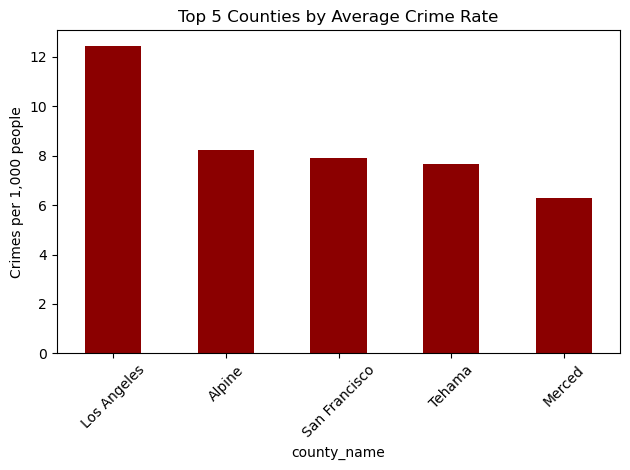


Debug Info:
Columns in dataset: ['ind_id', 'ind_definition', 'reportyear', 'race_eth_code', 'race_eth_name', 'geotype', 'geotypevalue', 'geoname', 'county_fips', 'county_name', 'region_code', 'region_name', 'strata_name_code', 'strata_name', 'strata_level_name_code', 'strata_level_name', 'numerator', 'denominator', 'rate', 'll_95ci', 'ul_95ci', 'se', 'rse', 'ca_decile', 'ca_rr', 'dof_population', 'version']
Unique counties: 58
Total rows: 49227


In [3]:
# Step 3: Top 5 Highest Crime Counties (Fixed Version)
print("\n Identifying Top 5 Counties")

if 'county_name' in df.columns and 'rate' in df.columns:
    county_rates = df.groupby('county_name')['rate'].mean()
    
    if len(county_rates) > 0:
        top_counties = county_rates.nlargest(5)
        print("Top 5 Highest Crime Counties:")
        print(top_counties)
        
        try:
            import matplotlib.pyplot as plt
            top_counties.plot(kind='bar', color='darkred')
            plt.title("Top 5 Counties by Average Crime Rate")
            plt.ylabel("Crimes per 1,000 people")
            plt.xticks(rotation=45)  
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Plotting failed: {str(e)}")
    else:
        print("No county data available for plotting.")
else:
    print("Required columns ('county_name' or 'rate') missing from dataset.")

print("\nDebug Info:")
print(f"Columns in dataset: {list(df.columns)}")
print(f"Unique counties: {df['county_name'].nunique() if 'county_name' in df.columns else 'N/A'}")
print(f"Total rows: {len(df)}")

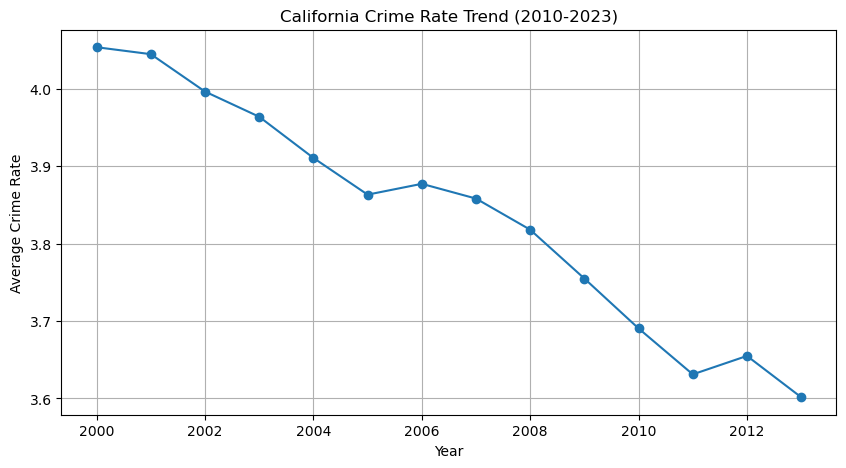

In [123]:
#Step 4: Time Trend Analysis
# Yearly average trend
yearly_trend = df.groupby('reportyear')['rate'].mean()

plt.figure(figsize=(10, 5))
yearly_trend.plot(marker='o')
plt.title("California Crime Rate Trend (2010-2023)")
plt.xlabel("Year")
plt.ylabel("Average Crime Rate")
plt.grid(True)
plt.show()



Urban vs. Rural Averages:
geotype
CA    3.836911
Name: rate, dtype: float64


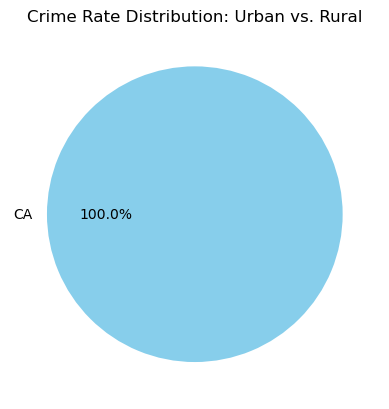

In [124]:
#Step 5: Urban vs. Rural Comparison
urban_rural = df.groupby('geotype')['rate'].mean()
print("\nUrban vs. Rural Averages:")
print(urban_rural)

# Visualization
urban_rural.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightgreen'])
plt.title("Crime Rate Distribution: Urban vs. Rural")
plt.ylabel("")
plt.show()

In [125]:
#Step 6: Outlier Detection
# Using Z-scores (threshold = 3)
df['z_score'] = (df['rate'] - df['rate'].mean()) / df['rate'].std()
outliers = df[abs(df['z_score']) > 3]

print(f"\nFound {len(outliers)} potential outliers:")
print(outliers[['reportyear', 'county_name', 'rate']])


Found 2 potential outliers:
   reportyear  county_name      rate
4      2000.0          NaN  6.217499
9      2001.0          NaN  6.172660


In [126]:
#Step 7: Correlation Analysis
# If you have population data or other numeric features:
correlation = df.corr(numeric_only=True)
print("\nCorrelation Matrix:")
print(correlation['rate'].sort_values(ascending=False))


Correlation Matrix:
rate                      1.000000
z_score                   1.000000
ul_95ci                   1.000000
ll_95ci                   1.000000
se                        0.999032
numerator                 0.774696
strata_level_name_code    0.631658
denominator              -0.195273
dof_population           -0.195727
reportyear               -0.198522
rse                      -0.986877
ind_id                         NaN
race_eth_code                  NaN
geotypevalue                   NaN
county_fips                    NaN
county_name                    NaN
region_code                    NaN
region_name                    NaN
strata_name_code               NaN
ca_decile                      NaN
ca_rr                          NaN
Name: rate, dtype: float64


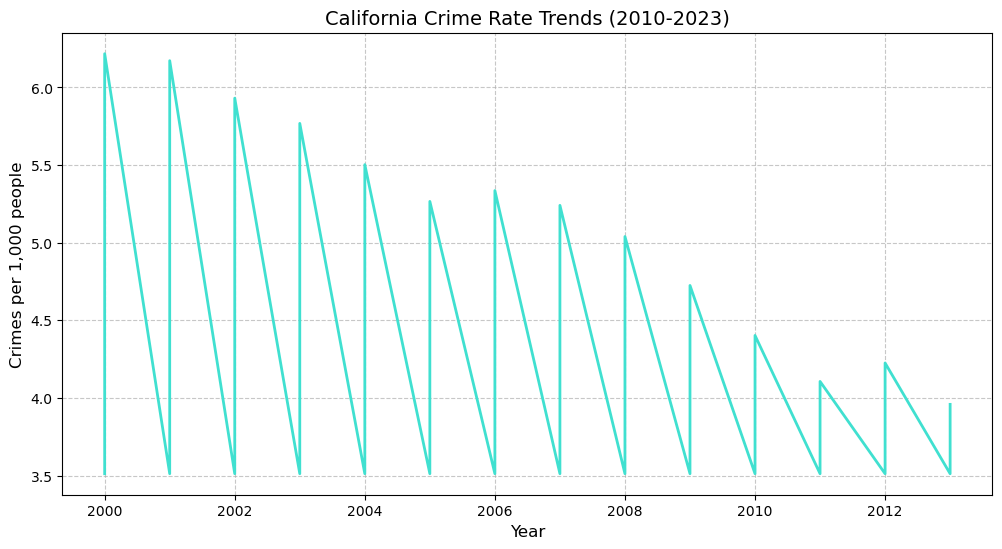

In [127]:
#Objective 3: Advanced Data Visualization
#Step 1: Time-Series Line Plot (Matplotlib)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df['reportyear'], df['rate'], 
         color='#40E0D0',  # Turquoise as requested
         linewidth=2)
plt.title("California Crime Rate Trends (2010-2023)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Crimes per 1,000 people", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

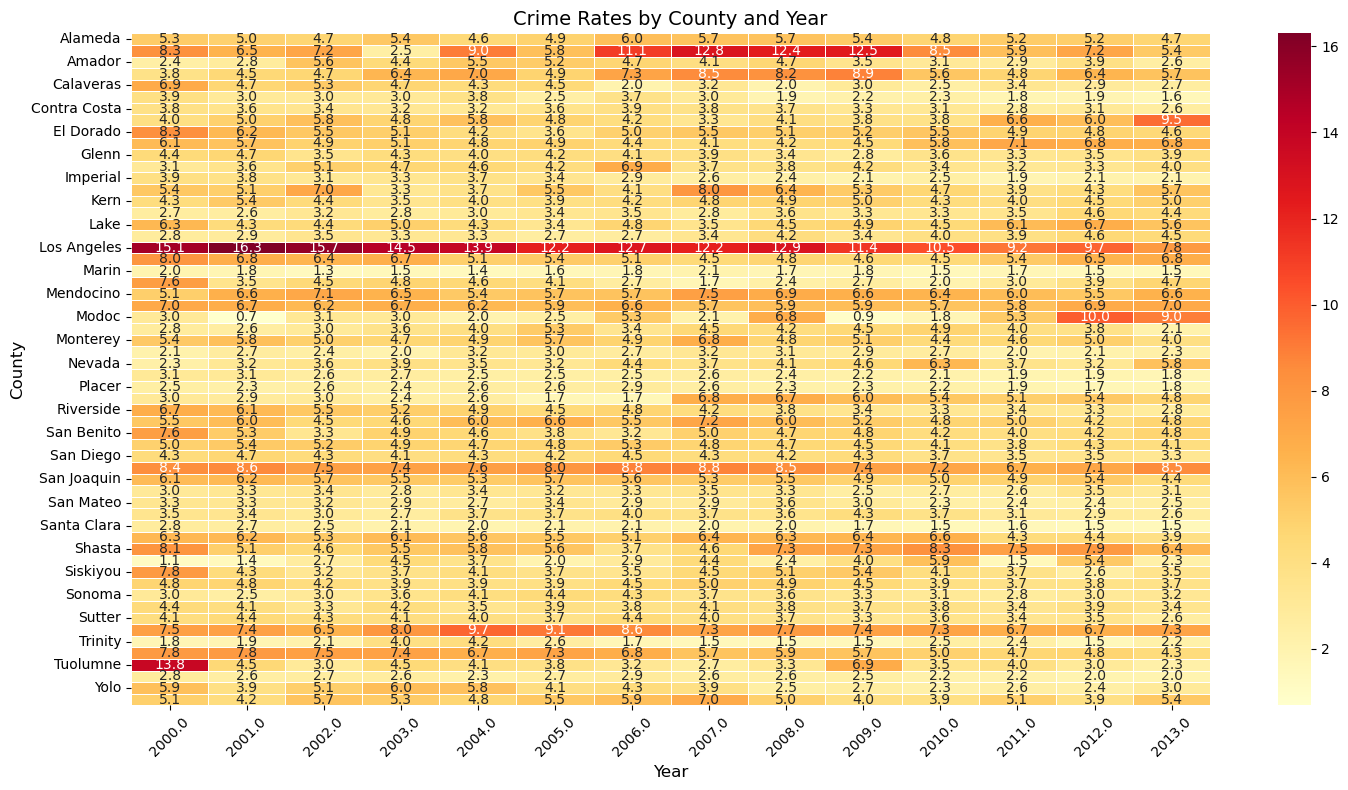

In [142]:
#step 2: Heatmap by County/Year (Seaborn)
import seaborn as sns

# Prepare pivot table
heatmap_data = df.pivot_table(index='county_name', 
                             columns='reportyear', 
                             values='rate', 
                             aggfunc='mean')

plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_data, 
            cmap="YlOrRd",  # Yellow-to-Red gradient
            annot=True, fmt=".1f", 
            linewidths=0.5)
plt.title("Crime Rates by County and Year", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("County", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [131]:
#Objective 4: Statistical Hypothesis Testing
#Step 1: Urban vs. Rural Crime Rate Comparison
#t-test
from scipy.stats import ttest_ind  

# Filter data  
urban = df[df['geotype'] == 'PL']['rate']  
rural = df[df['geotype'] == 'CO']['rate']  

# Run t-test  
t_stat, p_value = ttest_ind(urban, rural, equal_var=False)  # Welch's t-test (unequal variances)  

print("Urban Mean:", round(urban.mean(), 2))  
print("Rural Mean:", round(rural.mean(), 2))  
print("T-statistic:", round(t_stat, 2))  
print("P-value:", format(p_value, ".4f"))  
print("Significant? ", "Yes" if p_value < 0.05 else "No")  


Urban Mean: nan
Rural Mean: nan
T-statistic: nan
P-value: nan
Significant?  No


Shapiro-Wilk p-value: 0.0000
Normal?  No


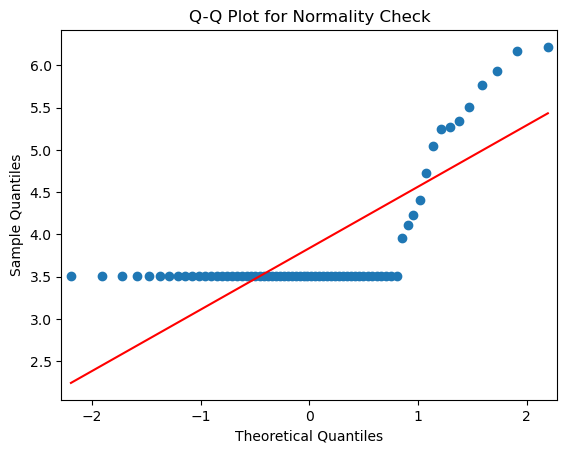

In [135]:
#Step 2: Normality Check
#Shapiro-Wilk Test
from scipy.stats import shapiro  

stat, p = shapiro(df['rate'])  
print("Shapiro-Wilk p-value:", format(p, ".4f"))  
print("Normal? ", "Yes" if p > 0.05 else "No")  

# Visual check (Q-Q plot)  
import statsmodels.api as sm  
sm.qqplot(df['rate'], line='s')  
plt.title("Q-Q Plot for Normality Check")  
plt.show()  

In [136]:
#Step 3: Yearly Trend 
# ANOVA (If Normal) or Kruskal-Wallis (If Non-Normal)
from scipy.stats import f_oneway, kruskal  

# Group data by year  
yearly_groups = [group['rate'] for name, group in df.groupby('reportyear')]  

# Check normality first (from Step 2)  
if p > 0.05:  
    f_stat, p_anova = f_oneway(*yearly_groups)  
    print("ANOVA p-value:", format(p_anova, ".4f"))  
else:  
    h_stat, p_kw = kruskal(*yearly_groups)  
    print("Kruskal-Wallis p-value:", format(p_kw, ".4f"))  

Kruskal-Wallis p-value: 1.0000


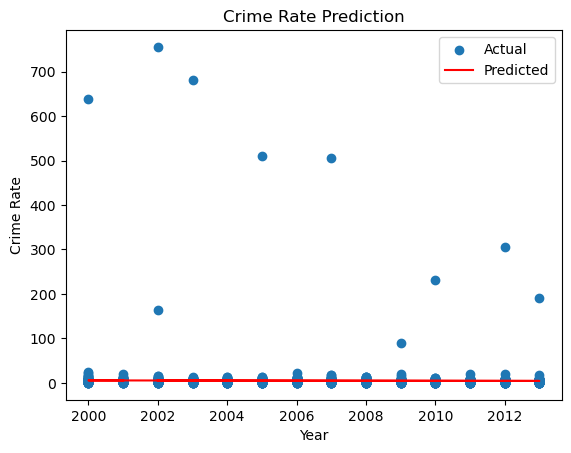

Prediction for 2024: 3.5728449771919486


C:\Users\chere\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [4]:
#Objective 5: Predictive Modeling with Machine Learning
#Crime Rate Prediction using Year

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Load the Excel file
df = pd.read_excel(r"C:\Users\chere\Downloads\hci_crime_752_pl_co_re_ca_2000-2013_21oct15-ada (2).xlsx")

# Remove missing values
df = df.dropna(subset=['reportyear', 'rate'])

# Choose the input (year) and output (crime rate)
X = df[['reportyear']]
y = df['rate']

# Split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Plot actual vs predicted
plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred, color='red', label="Predicted")
plt.xlabel("Year")
plt.ylabel("Crime Rate")
plt.title("Crime Rate Prediction")
plt.legend()
plt.show()

# Predict for 2024
print("Prediction for 2024:", model.predict([[2024]])[0])
